In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Model, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2")
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 5759.86it/s]

Ready!


In [2]:
text = "The king and queen ruled the kingdom"
inputs = tokenizer(text, return_tensors="pt")


fc_acts   = {}
proj_acts = {}

def make_fc_hook(layer_idx):
    def hook(module, input, output):
        fc_acts[layer_idx] = output.detach()
    return hook

def make_proj_hook(layer_idx):
    def hook(module, input, output):
        proj_acts[layer_idx] = output.detach()
    return hook

hooks = []
for i in range(12):
    h1 = model.h[i].mlp.act.register_forward_hook(
        make_fc_hook(i))
    h2 = model.h[i].mlp.c_proj.register_forward_hook(
        make_proj_hook(i))
    hooks.extend([h1, h2])

with torch.no_grad():
    outputs = model(**inputs)

for h in hooks:
    h.remove()

print(f"FC activation shape:   {fc_acts[0].shape}")
print(f"Proj activation shape: {proj_acts[0].shape}")
print(f"\nLayer 0 FC   — mean: {fc_acts[0].mean():.4f}, std: {fc_acts[0].std():.4f}")
print(f"Layer 0 Proj — mean: {proj_acts[0].mean():.4f}, std: {proj_acts[0].std():.4f}")

FC activation shape:   torch.Size([1, 7, 3072])
Proj activation shape: torch.Size([1, 7, 768])

Layer 0 FC   — mean: -0.0398, std: 0.2127
Layer 0 Proj — mean: 0.0198, std: 2.0302


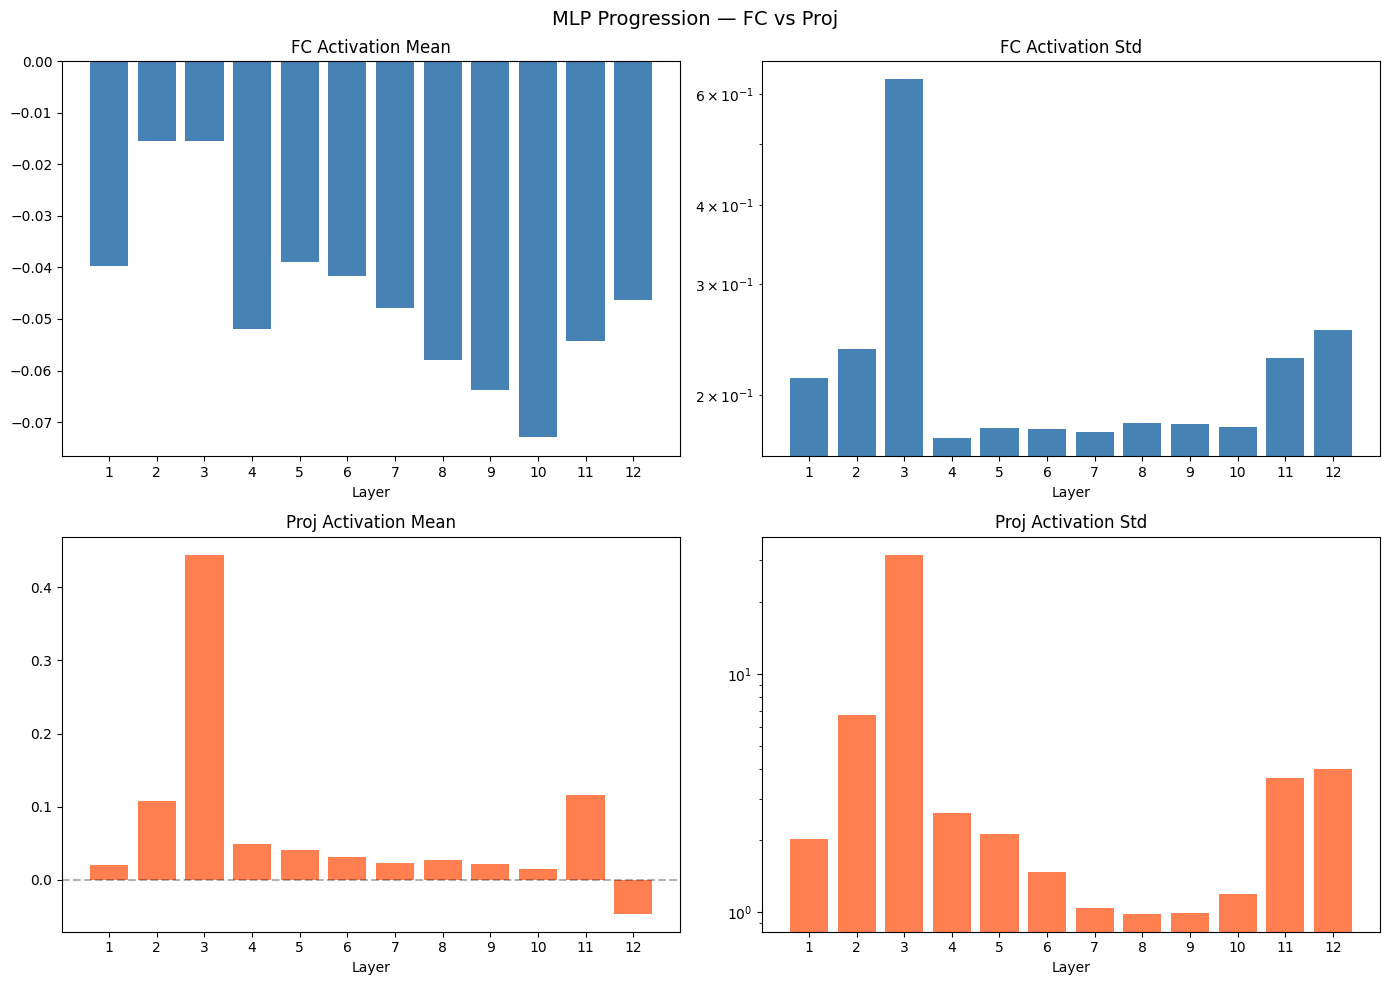

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

fc_means, fc_stds     = [], []
proj_means, proj_stds = [], []

for i in range(12):
    fc_means.append(fc_acts[i].mean().item())
    fc_stds.append(fc_acts[i].std().item())
    proj_means.append(proj_acts[i].mean().item())
    proj_stds.append(proj_acts[i].std().item())

layers  = range(1, 13)

# FC mean
axes[0,0].bar(layers, fc_means, color="steelblue")
axes[0,0].axhline(y=0, color="black", linestyle="--", alpha=0.3)
axes[0,0].set_title("FC Activation Mean")
axes[0,0].set_xlabel("Layer")
axes[0,0].set_xticks(layers)

# FC std
axes[0,1].bar(layers, fc_stds, color="steelblue")
axes[0,1].set_title("FC Activation Std")
axes[0,1].set_xlabel("Layer")
axes[0,1].set_xticks(layers)
axes[0,1].set_yscale("log")

# Proj mean
axes[1,0].bar(layers, proj_means, color="coral")
axes[1,0].axhline(y=0, color="black", linestyle="--", alpha=0.3)
axes[1,0].set_title("Proj Activation Mean")
axes[1,0].set_xlabel("Layer")
axes[1,0].set_xticks(layers)

# Proj std
axes[1,1].bar(layers, proj_stds, color="coral")
axes[1,1].set_title("Proj Activation Std")
axes[1,1].set_xlabel("Layer")
axes[1,1].set_xticks(layers)
axes[1,1].set_yscale("log")

plt.suptitle("MLP Progression — FC vs Proj", fontsize=14)
plt.tight_layout()
plt.show()


* Fully Connected (FC, 3072 dimensions) and Projection (Proj, 768 dimensions) layers show different patterns.
* Both exhibit a spike in Layer 3 — a consistent finding.
* FC activations tend to be negative (due to the GELU effect).
* Projection activations tend to be positive (as they contribute to the output).
